### Librerias e importaciones

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from src.preprocessing import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from src.data_splitting import train_val_split
from src.plots import eda_visualizacion_suvs, plot_precio_segun_antiguedad_km, plot_precio_segun_rango_ant, plot_dispersion_por_marca, plot_grupo_especifico
from src.modelos.xgboost import entrenar_xgboost, entrenar_xgboost_ohe, grid_search
from src.modelos.regresion_lineal import entrenar_regresion_lineal, definir_regularizacion
from src.utils import estandarizar
from src.deteccion_outliers import flagear_outliers_por_grupo, reportar_outliers_por_grupo, ver_outliers, eliminar_outliers_grupo, eliminar_outliers_por_corte
from src.metrics import rmse, mae, r2

In [3]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

### EDA

**Preprocessing**

In [4]:
data = pd.read_csv('../data/raw/pf_suvs.csv')

In [5]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())



 Dataset ALEATORIO
       Unnamed: 0      Marca        Modelo     Año  \
5194         5194        Kia      Sportage  2012.0   
16931       16931  Chevrolet       Tracker  2016.0   
1573         1573        BMW            X6  2010.0   
3044         3044       Fiat         Pulse  2025.0   
12777       12777       Audi  Q3 Sportback  2024.0   

                             Versión     Color Tipo de combustible  Puertas  \
5194             2.0 Ex 2wd 163cv At    Blanco           Nafta/GNC      5.0   
16931                  1.8 Ltz 140cv     Negro               Nafta      5.0   
1573   3.0 Xdrive 35i Sportive 306cv     Negro               Nafta      5.0   
3044               1.3 Gse Drive Cvt      Gris               Nafta      5.0   
12777    1.4 35tfsi Sportback 150 Cv  Plateado               Nafta      5.0   

      Transmisión Motor Tipo de carrocería Con cámara de retroceso Kilómetros  \
5194   Automática   2.0                SUV                      No   215000.0   
16931  Automática 

In [6]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [7]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>El análisis exploratorio permitió detectar la existencia de valores faltantes en diversas variables descriptivas del vehículo, entre ellas Color, Transmisión, Motor y Con cámara de retroceso. Debido a que estas variables pueden influir significativamente en el valor de mercado de una SUV, se optó por imputar los datos faltantes en lugar de descartar las observaciones correspondientes, preservando así el tamaño de la muestra disponible para entrenamiento.</em>
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>Por otra parte, se observó que gran parte de los atributos del dataset se encuentran representados mediante variables categóricas de tipo texto. Dado que los algoritmos de aprendizaje supervisado utilizados trabajan sobre representaciones numéricas, será necesario transformar dichas variables mediante One-Hot Encoding, generando una codificación binaria que permita incorporar esta información al modelo sin introducir relaciones artificiales entre categorías.<em>
</p>

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

**Justificacion de desiciones tomadas**


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
1. <code>Unnamed: 0</code> actúa únicamente como identificador de cada publicación y no aporta información relevante para la predicción del precio, por lo que fue eliminada.
Para <code>Tipo de carrocería</code>, el dataset contiene exclusivamente vehículos SUV, por lo que también fue eliminada.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
2. <code>Cambio de moneda a USD</code>: Al tratarse de la variable objetivo del problema, fue necesario unificar todas las observaciones en una única moneda (USD) de referencia para garantizar la comparabilidad entre vehículos. Se eliminó la columna ya que no aportaba información.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
3. <code>Título</code>: Gran parte de la información contenida en esta columna ya se encuentra representada en otras variables estructuradas del dataset (<code>Marca</code>, <code>Modelo</code>, <code>Motor</code>, <code>Versión</code>, etc.), por lo que se decidió eliminarla para evitar redundancia.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
4. <code>Imputación de Puertas</code>: se observaron valores inconsistentes en la variable <code>Puertas</code>. Dado que el conjunto de datos contiene exclusivamente SUVs, se decidió homogeneizar los valores restantes utilizando cinco puertas como valor por defecto.</p>


In [8]:
display(data["Puertas"].value_counts().sort_index())

Puertas
2.0           10
3.0          105
4.0          399
5.0        17731
6.0            3
7.0            2
60252.0        4
Name: count, dtype: int64

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<p>5. <code>Motor</code>: presentaba únicamente 38 valores faltantes (menos del 0.3% del dataset). Debido a su baja proporción, se optó por eliminar dichas observaciones en lugar de imputarlas para evitar introducir ruido artificial. A su vez, los datos estaban en <code>str</code> se cambiaron a valor numérico.</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<p>Además la columna contenía formatos muy heterogéneos, combinando cilindrada, tipo de motor y descripciones comerciales (por ejemplo: <em>"2.0 TSI"</em>, <em>"1.5 Turbo"</em>, <em>"Inyección Multipunto"</em> o <em>"Turboalimentado"</em>).</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<p>Para preservar la mayor cantidad de información posible se descompuso en varias variables:
<strong>Motor_Litros</strong>, <strong>Motor_Turbo</strong>, <strong>Motor_Multipunto</strong>, <strong>Motor_Diesel</strong>, <strong>Motor_Hibrido</strong>, <strong>Motor_Litros_Faltante</strong>.</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<p>De esta forma se evita descartar observaciones y se conserva información relevante sobre la motorización del vehículo en un formato apto para modelos supervisados.</p>


In [9]:
nulos_motor = data["Motor"].isna().sum()
total = len(data)

print(f"Nulos en Motor: {nulos_motor}")
print(f"Total de registros: {total}")
print(f"Porcentaje de nulos: {100*nulos_motor/total:.3f}%")

Nulos en Motor: 38
Total de registros: 18254
Porcentaje de nulos: 0.208%


In [10]:
print(data["Motor"].unique().tolist())

['1.5', '2.0 L 230 CV  350 TSI', '1.4', '2.4', '1.5 TURBO', '2.0', '3.6', '1.8', '1.0', '1.3', '1.2 TURBO', '1.2', '1.6', 'Nafta 2.0 (148cv) + Electrico (184.5cv)', '3.0', '2.2', '2.5', '1', '2.5l Hibrida', '2.8', '2.7', 'TURBOALIMENTADO', 'TURBO DIESEL INYECCION', '4.8', '2.9', '1.3T', 'INYECCION MULTI PUNTO', nan, 'diesel', '4.4', '3.0 440HP', '2.0 hurrican 4 272 cv 400nm', '6.4', '5.2', '1.5t', '1.4 TFSI', '2.3', '4.7', '2.0 TDI 140CV', '3.7', '3.2', '1500', '3.8', '1.3 TURBO', '4.5', '3', '2', '2.0 TURBO', '4.0 Nafta', '1.8L', '192 HP', '1.6 Naftero', '5.0', '1.5 TURBO 185 HP', 'P8 (408hp)', '1,3 t 175 cv 270 Nm', '1.6 Turbo', '4.2', '4.0', '1.0 tsi', '1.5 16V', '1.0 200 TSI', '1.8 de 140 hp', '2.0 350TSI', '3.5', '1.3L', '1.3 Turbo', '1.0 TURBO', '1.3 TURBO NAFTA 175CV AT9', 'Motor naftero 1.8 105 CV 161 Nm', '1.0 3 CILINDROS', 'v8 302', '3.3 V6 TD 304cv 700 NM de torque', '1.5 turbo', 'TURBO 2 LITROS', '1.6 MSI Nafta', '1.0T', '6.1', '2500', '2.4L', 'V6 PLUG IN HYBRID 460HP', '2.

In [11]:
motor_extraido = (
    data["Motor"]
    .str.extract(r'(\d+[.,]\d+)')[0]
)

perdidos = data[
    data["Motor"].notna() &
    motor_extraido.isna()
]

print(len(perdidos))
display(perdidos["Motor"].value_counts().head(10)) 

429


Motor
INYECCION MULTI PUNTO      157
TURBOALIMENTADO             82
1                           67
2                           41
TURBO DIESEL INYECCION      10
Turbo 140 CV                 4
1600                         3
1500                         2
192 HP                       2
V6 PLUG IN HYBRID 460HP      2
Name: count, dtype: int64

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
En los casos donde la cilindrada no pudo recuperarse, se incorporó la variable indicadora <strong>Motor_Litros_Faltante</strong>, permitiendo al modelo distinguir entre motores con cilindrada conocida y desconocida.

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
6. <code>Kilómetros</code>: Se transformó a valor numérico para garantizar un tratamiento consistente. Además se crea el feature <code>0km</code> que indica si el vehículo es nuevo o usado. Posteriormente se incorporó <code>Log_Km</code> para reducir la asimetría observada en la distribución original.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
7. <code>Descripción</code>: contiene texto libre que no puede ser utilizado directamente por modelos de regresión tradicionales. Se construyó un score basado en palabras clave positivas y negativas asociadas al estado general del vehículo, documentación, mantenimiento y equipamiento. El resultado se transformó en una escala numérica entre 1 y 10.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
7. <code>Descripción</code>: se aplicó <strong>TF-IDF</strong> (<em>Term Frequency - Inverse Document Frequency</em>) para vectorizar las descripciones, asignando mayor peso a las palabras relevantes y menor a las más frecuentes en todo el dataset. Dado que esto genera un vector de alta dimensionalidad, se aplicó <strong>SVD</strong> para reducir la dimensionalidad a 20 componentes, preservando la mayor parte de la información semántica.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
8. <code>Marca</code>: Se unificaron las muestras para evitar duplicados y/o reconocimiento erróneo de una marca.
A su vez, se combinó <code>Marca</code> y <code>Modelo</code> en una sola feature <code>Marca_Modelo</code>.
</p>


In [12]:
print(data["Marca"].unique().tolist())

['Ford', 'Volkswagen', 'Jeep', 'BAIC', 'Kia', 'Hyundai', 'Porsche', 'Peugeot', 'Fiat', 'Chevrolet', 'Citroën', 'BMW', 'Audi', 'Honda', 'Nissan', 'Mercedes-Benz', 'Renault', 'Suzuki', 'Toyota', 'D.S.', 'Chery', 'Daihatsu', 'SsangYong', 'Dodge', 'JAC', 'Land Rover', 'Alfa Romeo', 'Haval', 'Volvo', 'Lifan', 'Mini', 'D·S', 'Mitsubishi', 'Range Rover', 'Hiunday', 'Jetour', 'GWM', 'KAIYI', 'Lexus', 'Isuzu', 'Rrenault', 'Subaru', 'Jetur', 'DS AUTOMOBILES', 'hiunday', 'Jaguar', 'Vol']


8. `Año`: Considerando que se tiene 1 valor extremo, claro outlier o error de carga, se elimina la muestra ya que no aporta informacion ni se pierde al no tenerla.

In [13]:
display(pd.DataFrame(data['Año'].describe()))

,Año
count,18254.000000
mean,2042.796209
std,3217.260996
min,1981.000000
25%,2016.000000
50%,2019.000000
75%,2024.000000
max,436694.000000


In [14]:
print((data["Año"] > 2025).sum()) 
print(data[data["Año"] > 2025]["Año"].unique()) 

1
[436694.]


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
9. <code>Color</code>: considerando que se tienen colores definidos en mayuscula y minuscula, femenino y masculino, se unifican todas las muestras a minuscula masculino. A la vez, al haber pocas muestras de colores especificos, tales como 'gris titane' (1 sola muestra) o 'gris artense', el modelo no aprendera de estas, por lo que resulta conveniente unificarlas dentro de los colores genericos (en el caso de los ejemplos, dentro de 'gris). Asi se redujo la cardinalidad sin perder informacion relevante.
</p>

In [15]:
print(data["Color"].value_counts().to_string())

Color
Gris                             5468
Blanco                           4809
Negro                            2825
Plateado                         1427
Azul                             1121
Rojo                             1118
Marrón                            253
Dorado                            190
Verde                             135
Beige                             125
Celeste                            93
Naranja                            73
Gris oscuro                        43
Violeta                            33
Bordó                              29
Amarillo                           24
Rosa                                8
Plata                               7
Otro                                6
Blanca                              4
Acero                               4
BLANCA                              3
Café                                3
Negra                               3
Gris plata                          3
steel_blue                          2
GRIS S

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
10. <code>Versión</code>: se agruparon las versiones en tres categroias, Version_Base, Version_Intermedia  y Version_Premium. Se clasificó utilizanod palabras clave frecuentes asociadas al nivel del equipamiento del veehículo.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
11. <code>Con Camara de retroceso</code>: tiene una gran cantidad de valores faltantes. Antes de realizar cualquier imputación estadística, se intentó recuperar esta información buscando referencias a cámaras o sensores de estacionamiento dentro de la descripción de cada vehículo. Cuando no fue posible inferir la presencia de la característica, el registro fue etiquetado como "Desconocido", permitiendo conservar la observación sin introducir supuestos adicionales.
</p>

In [16]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

Tamaño final del dataset ->  (18205, 21)


**NUEVO DATASET**

In [17]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
          Año   Color Tipo de combustible  Puertas Transmisión  \
18189  2025.0    azul               Nafta      5.0  Automática   
13651  2025.0  blanco               Nafta      5.0  Automática   
13093  2025.0  blanco               Nafta      5.0  Automática   
5747   2025.0   negro               Nafta      5.0  Automática   
8380   2015.0  blanco               Nafta      5.0      Manual   

      Con cámara de retroceso  Kilómetros        Precio  \
18189             Desconocido         NaN  42302.771855   
13651                      Sí         0.0  33500.000000   
13093             Desconocido         0.0  28100.000000   
5747              Desconocido         0.0  28989.339019   
8380              Desconocido    100000.0  12793.176972   

                                             Descripción Tipo de vendedor  \
18189  ¡Bienvenido! Tu nuevo auto te espera en nuestr...           tienda   
13651  PEUGEOT 2008 GT 1.0 T200 ,white nacar, tope de...    concesi

In [18]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Año,float64,0,38
Color,str,379,16
Tipo de combustible,str,0,8
Puertas,float64,0,2
Transmisión,str,11,4
Con cámara de retroceso,str,0,3
Kilómetros,float64,431,2120
Precio,float64,0,2909
Descripción,str,0,12104
Tipo de vendedor,str,0,3


In [19]:
data_pre.to_csv("../data/processed/data_pre__limpio_EDA.csv", index=False)

DETECCION DE OUTLIERS

In [20]:
df_outliers = data_pre.copy()

In [21]:
df_outliers = flagear_outliers_por_grupo(df_outliers, grupo_col = "Marca_Modelo", col = "Precio", k = 1.5, min_registros = 10)

[Precio] Outliers detectados: 544 (2.99%)
Grupos chicos no filtrados (<10 registros): 49


In [23]:
resu = reportar_outliers_por_grupo(df_outliers, grupo_col = "Marca_Modelo", col = "Precio", top_n = 20)
display(resu.round(2))

,n_outliers,precio_min,precio_max,precio_mediana
Marca_Modelo,,,,
Renault_Duster,89,111.00,45492.54,27742.42
Fiat_Pulse,40,1108.74,13219.62,10234.54
BAIC_X55,36,17900.00,45700.00,44150.00
Hyundai_Tucson,34,48900.00,58900.00,58000.00
Honda_HR-V,26,6500.00,40912.58,38250.00
BMW_X6,24,135000.00,268900.00,179999.50
BMW_X1,23,65900.00,89900.00,84000.00
Citroën_C3 Aircross,20,10157.78,18763.33,13816.63
Honda_CR-V,17,35000.00,75275.00,54000.00


In [24]:
ver_outliers(df_outliers, col = "Precio", n = 20)

,Marca_Modelo,Precio,Año,Kilómetros
6616,Land Rover_Range Rover Sport,610000.000000,2024.0,0.0
6336,Porsche_Cayenne,345000.000000,2022.0,14000.0
17423,Land Rover_Range Rover Sport,315000.000000,2025.0,0.0
2820,Land Rover_Range Rover Sport,315000.000000,2025.0,0.0
11199,Volkswagen_Nivus,298081.023454,2024.0,0.0
15900,BMW_X6,268900.000000,2025.0,0.0
10264,Porsche_Macan,268000.000000,2025.0,0.0
9638,BMW_X6,264900.000000,2025.0,0.0
11510,Porsche_Cayenne,259000.000000,2025.0,0.0
9883,Porsche_Cayenne,258000.000000,2025.0,0.0


Land Rover_Range Rover Sport — 18 registros
Q1=34,250.00
Q3=123,425.00
IQR=89,175.00
Rango válido: [-99,512.50, 257,187.50]
Outliers detectados: 3


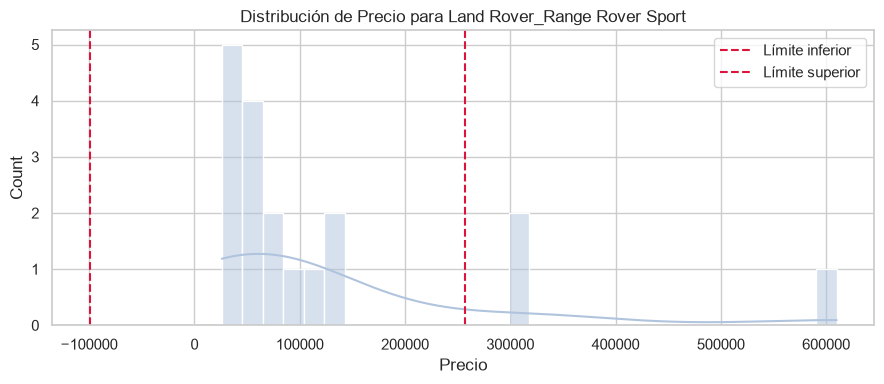

Renault_Duster — 1047 registros
Q1=11,940.30
Q3=17,304.90
IQR=5,364.61
Rango válido: [3,893.39, 25,351.81]
Outliers detectados: 89


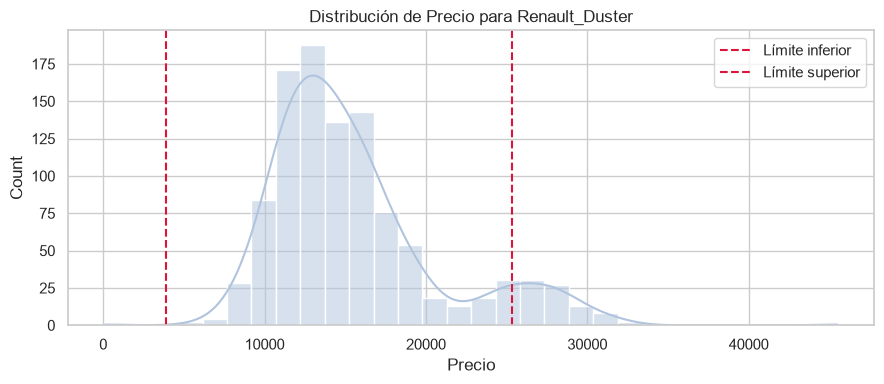

Jeep_Wrangler — 109 registros
Q1=38,500.00
Q3=90,000.00
IQR=51,500.00
Rango válido: [-38,750.00, 167,250.00]
Outliers detectados: 0


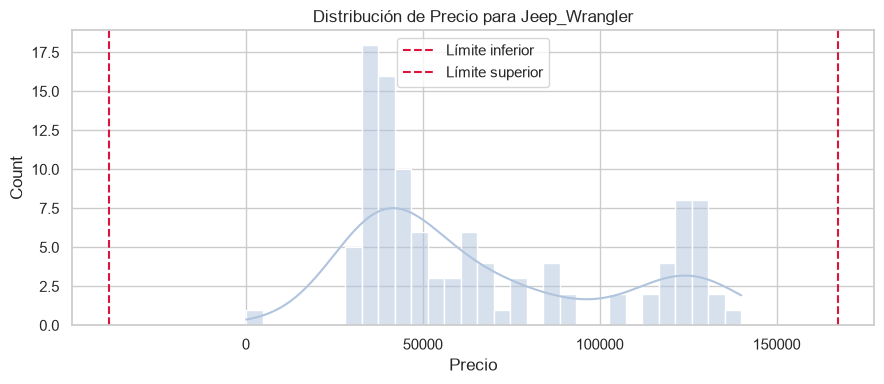

In [25]:
vista_outliers_marca= plot_grupo_especifico(df_outliers, grupo="Land Rover_Range Rover Sport", k=1.5)
vista_outliers_marca_= plot_grupo_especifico(df_outliers, grupo="Renault_Duster", k=1.5)
vista_outliers_marca_= plot_grupo_especifico(df_outliers, grupo="Jeep_Wrangler", k=1.5)

*Lo que se logra notar es que hay Precios < 5000 USD los cuales el IQR no logra detectar, tal q se opta por eliminar aquellos precios para evitar outliers por Marca_Modelo.*

In [26]:
len(df_outliers[df_outliers["Precio"] <= 5000])

25

kilometros outliers

In [27]:
display(
    data_pre[data_pre["Kilómetros"] > 500000]
    [["Marca_Modelo", "Precio", "Año", "Kilómetros"]]
    .sort_values("Kilómetros", ascending=False)
)

,Marca_Modelo,Precio,Año,Kilómetros
7614,Chevrolet_Blazer,7931.769723,2000.0,9999999.0
14106,Toyota_Hilux SW4,21748.400853,2009.0,1700000.0
16287,Nissan_Kicks,23027.718550,2020.0,1111111.0
14201,Peugeot_2008,18336.886994,2025.0,1111111.0
6479,Renault_Duster,7500.000000,2013.0,1111111.0
6109,Renault_Duster,12963.752665,2013.0,1111111.0
7156,Ford_Bronco,45000.000000,1981.0,1111111.0
11008,Suzuki_Jimny,11000.000000,1999.0,1111111.0
16688,Nissan_Kicks,23027.718550,2020.0,1111111.0
6118,Renault_Duster,14000.000000,2018.0,1111111.0


creo datasets sin outliers

In [28]:
#elimina llas muestras vuyo precio queda fuera del rango iqr en su marca modelo
data_pre_sin_outliers= eliminar_outliers_grupo(df_outliers)
#elimina km >= 500.000 
data_pre_sin_outliers = data_pre_sin_outliers [data_pre_sin_outliers["Kilómetros"] <= 500000].copy()

print("Original:", data_pre.shape)
print("IQR + KM limpio:", data_pre_sin_outliers.shape)

#elimina precio <5000 USD
data_pre_sin_out_final = eliminar_outliers_por_corte(
    data_pre_sin_outliers,
    precio_min=5000
)

print("IQR + KM + > 5000:", data_pre_sin_out_final.shape)

Registros antes: 18205
Registros después: 17661
Eliminados: 544 (2.99%)
Original: (18205, 21)
IQR + KM limpio: (17224, 21)
Eliminados: 19 (0.11%)
IQR + KM + > 5000: (17205, 21)


In [ ]:
data_pre_sin_out_final.to_csv("../data/processed/data_pre_SIN_OUT.csv", index=False)

**VISUALIZACION DEL EDA HASTA AHORA**

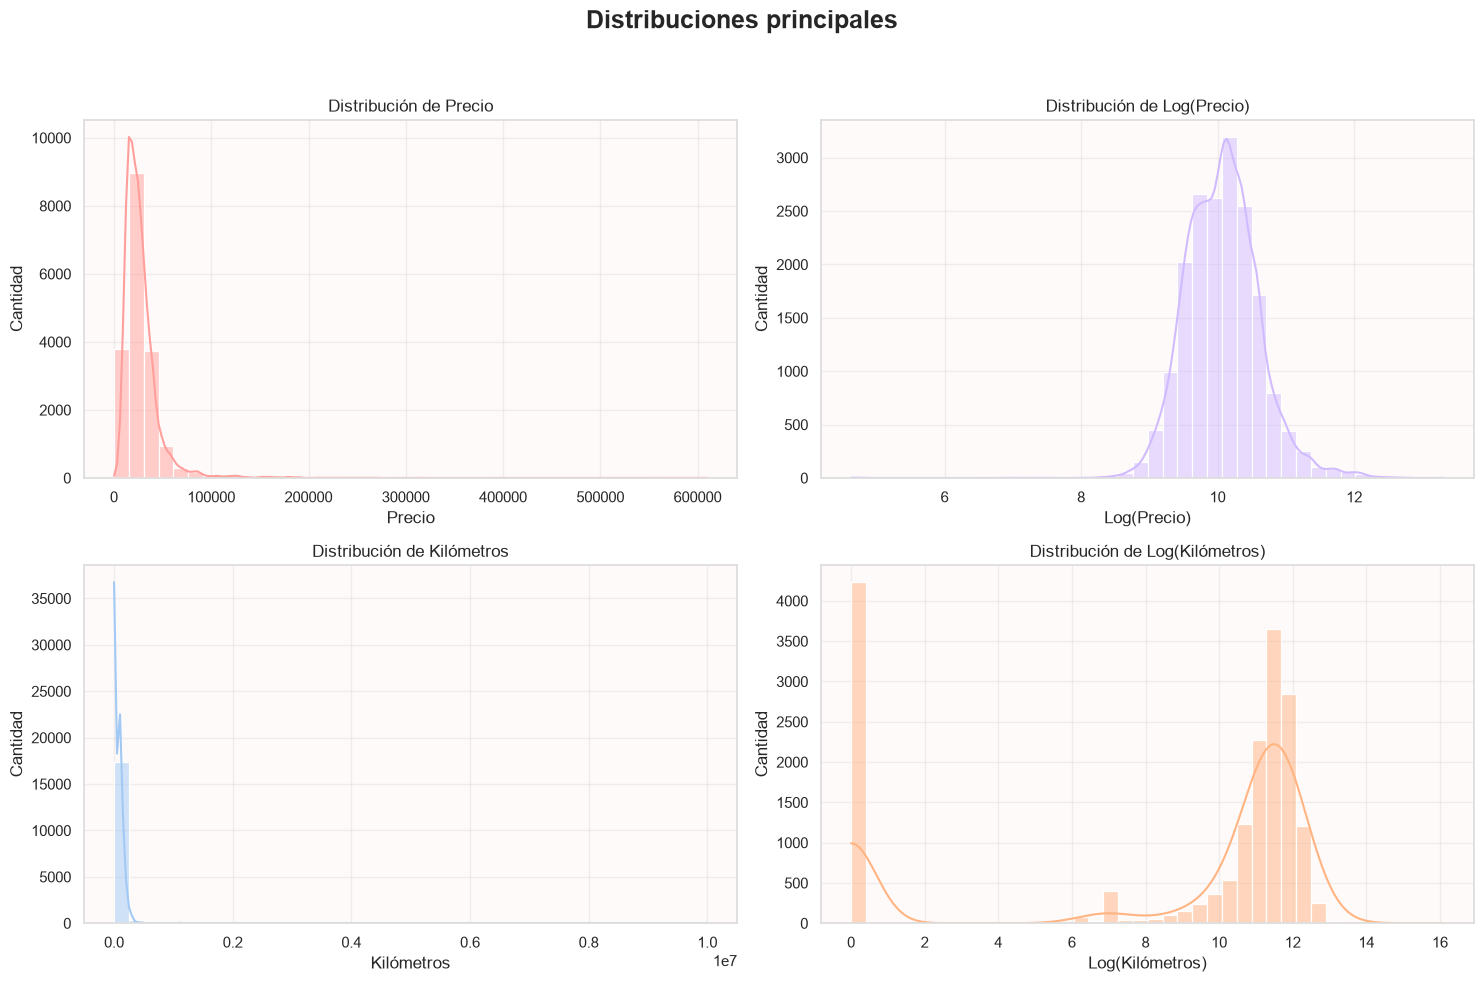

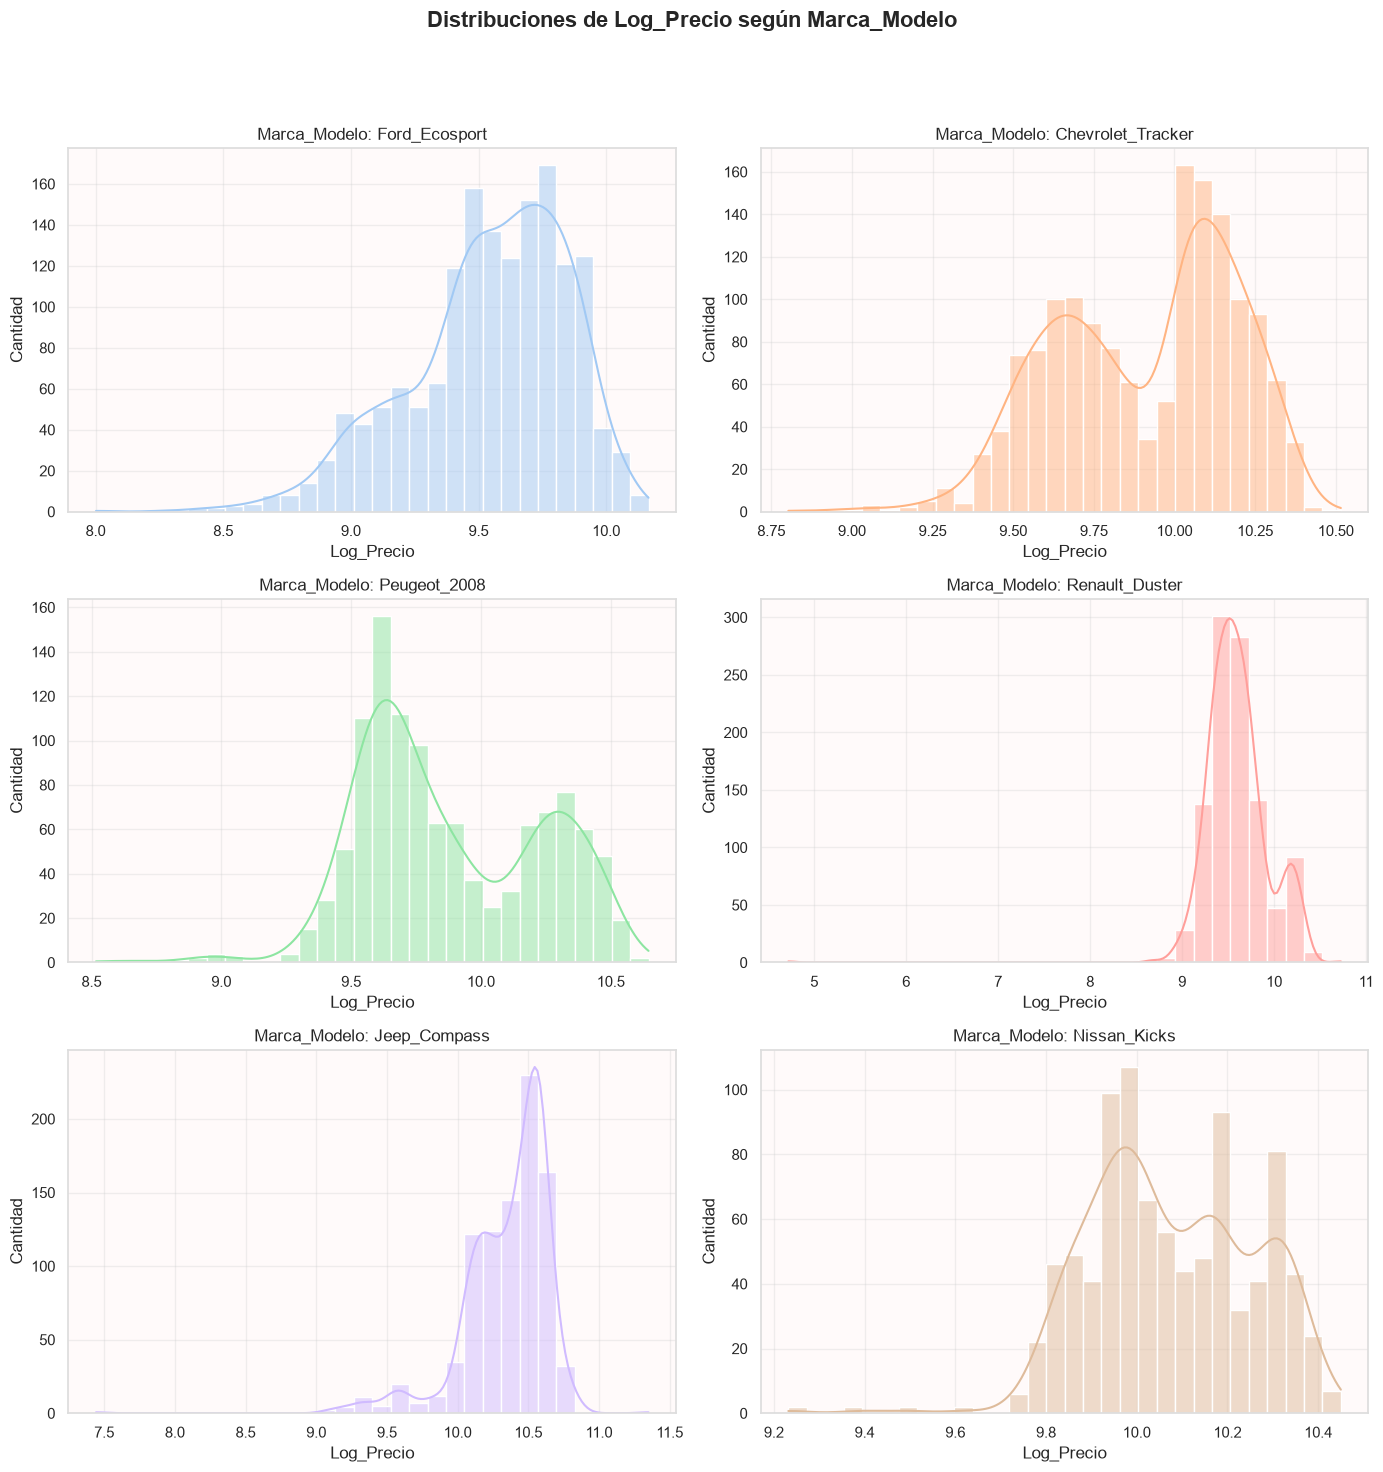

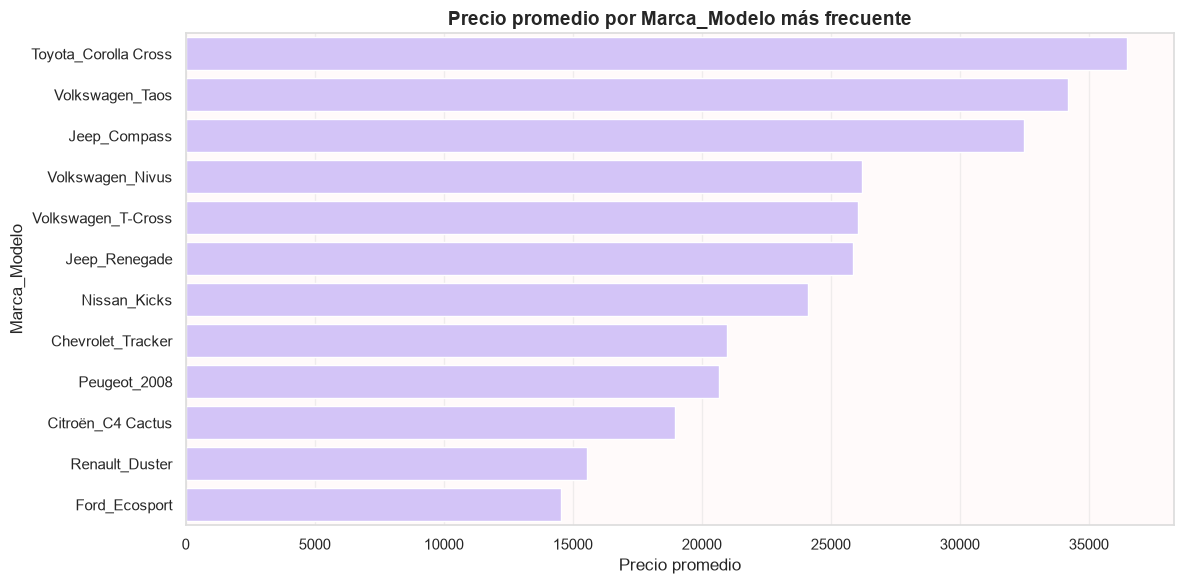

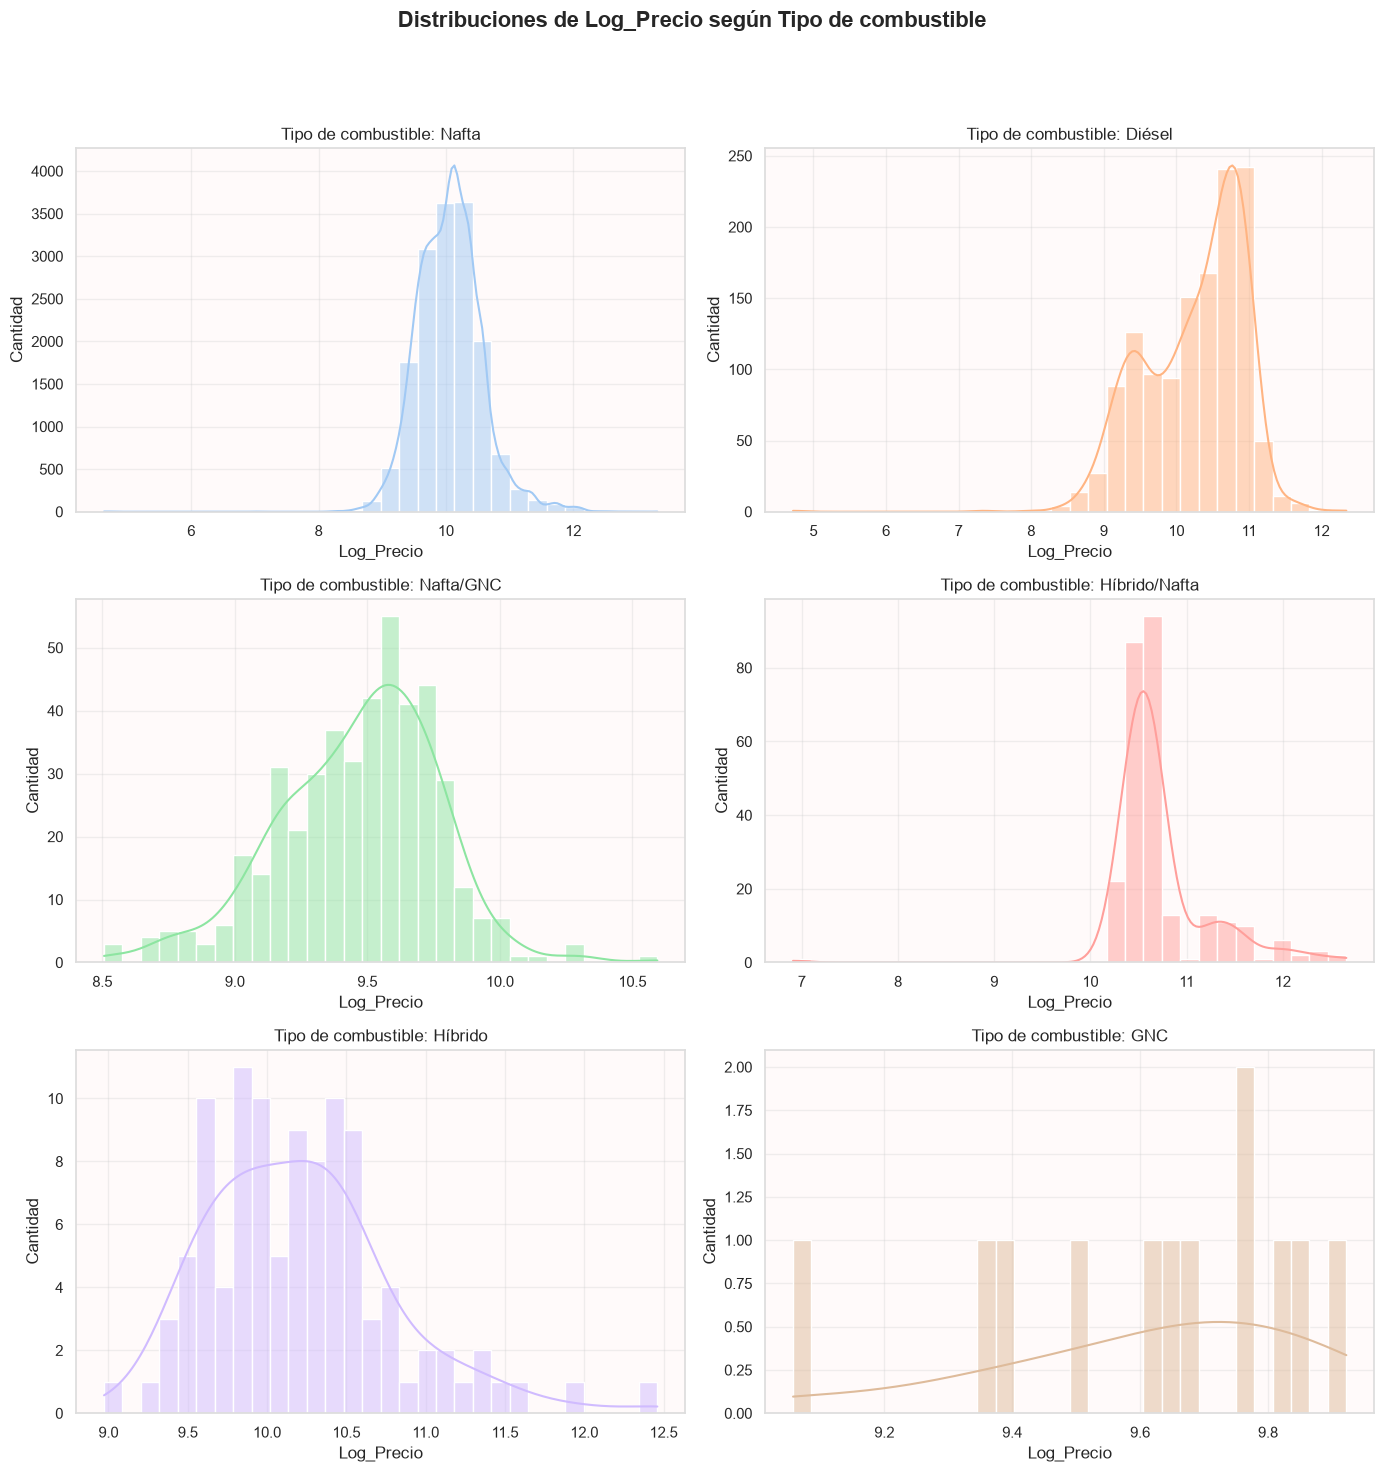

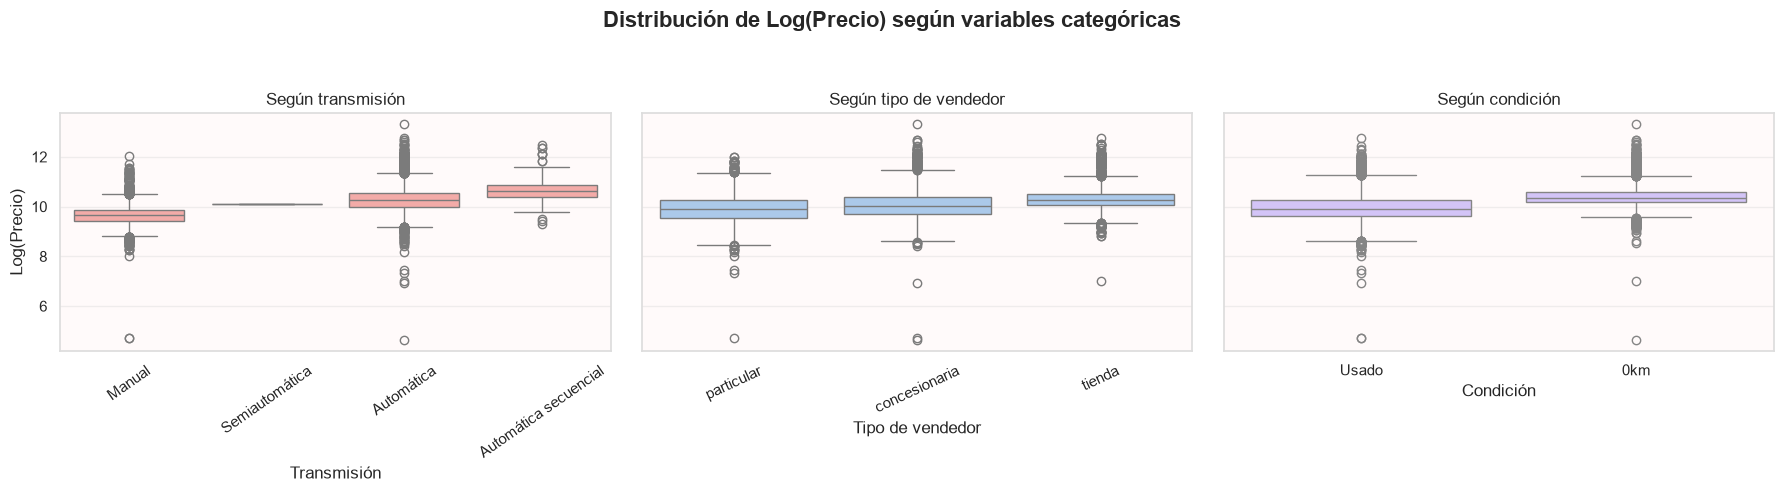

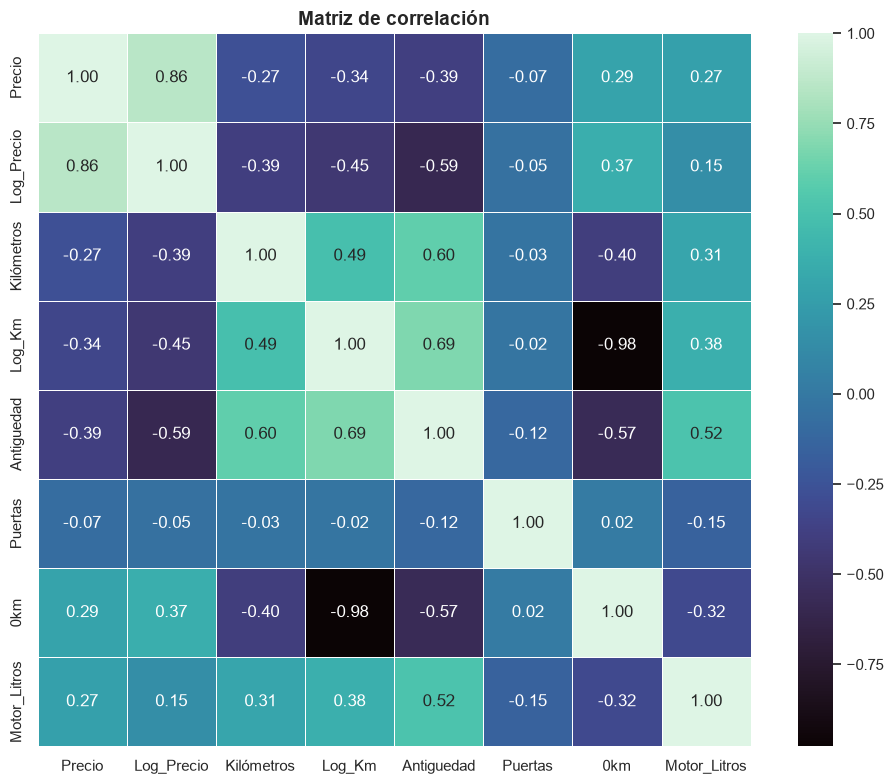

In [29]:
#Plots
eda_visualizacion_suvs(data_pre)

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>Se observan diferencias de precio según el modelo, el combustible y la condición del vehículo. Además, tanto el kilometraje como la antigüedad presentan una relación negativa con el precio. Las transformaciones logarítmicas permiten visualizar mejor estas relaciones al reducir la asimetría de las distribuciones originales.</em>
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Para terminar con el <em><strong>preprocesamiento de datos</strong></em>, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "color", "transmision", "camara", "Kilómetros", "Motor_Litros" evitando el data leakage.
</p>

In [30]:
nulos = data_pre.isnull().sum()

if (nulos > 0).any():
    print("Columnas con NaN:")
    print(nulos[nulos > 0])
else:
    print("No quedan NaN en el dataset")

Columnas con NaN:
Color           379
Transmisión      11
Kilómetros      431
Motor_Litros    427
dtype: int64


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
11. <strong>Imputaciones realizadas después del split</strong>: todas las imputaciones basadas en estadísticas (moda o mediana) fueron calculadas exclusivamente sobre el conjunto de entrenamiento y posteriormente aplicadas al conjunto de validación, evitando data leakage.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Color</strong>: los valores faltantes se completaron utilizando la moda del color para cada vehículo (`Marca_Modelo`). Si un modelo no poseía suficientes observaciones, se utilizó la moda global del conjunto de entrenamiento.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Transmisión</strong>: debido a la baja cantidad de valores faltantes, se utilizó un imputador KNN entrenado sobre el conjunto de entrenamiento. La imputación se realizó considerando vehículos con características similares y posteriormente se reconstruyó la categoría original.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Kilómetros</strong>: los valores faltantes se completaron utilizando la mediana del kilometraje correspondiente al año del vehículo. En caso de no existir suficientes observaciones para un determinado año, se utilizó la mediana global del conjunto de entrenamiento.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Motor_Litros</strong>: cuando no fue posible recuperar la cilindrada a partir de la descripción original del motor, el valor faltante se imputó utilizando la mediana calculada sobre el conjunto de entrenamiento. Adicionalmente, se conservó la variable indicadora `Motor_Litros_Faltante` para que el modelo pudiera distinguir los registros originalmente incompletos.
</p>

In [31]:
train, val = train_val_split(data_pre)

Tamaño conjunto de entrenamiento -> (14564, 21), 
Tamaño conjunto de validación -> (3641, 21)


In [32]:
#Preprocessing post split usando los parametros del entrenamiento
x_train, x_val = preprocesamiento_post_split(train, val)

In [33]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ["Marca_Modelo","Color",'Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
X_train_final, X_val_final = onehot_encoding(x_train, x_val, columnas_oh)

In [34]:
print('Tamaño train final -> ', X_train_final.shape)
print('Tamaño val final -> ', X_val_final.shape)

Tamaño train final ->  (14564, 215)
Tamaño val final ->  (3641, 215)


In [ ]:
# print('Final del preprocesamiento sobre Entrenamiento')
# summary = pd.DataFrame({
#     "dtype": X_train_final.dtypes,
#     "nulos": X_train_final.isnull().sum(),
#     "unicos": X_train_final.nunique()
# })
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

# display(summary)

In [ ]:
# print('Final del preprocesamiento sobre Validación')
# summary_ = pd.DataFrame({
#     "dtype": X_val_final.dtypes,
#     "nulos": X_val_final.isnull().sum(),
#     "unicos": X_val_final.nunique()
# })
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# display(summary_)

In [35]:
#Cargamos el set de entrenamiento y validacion a csv para ver los cambios
X_train_final.to_csv("../data/processed/X_train_EDA.csv", index=False)
X_val_final.to_csv("../data/processed/X_val_EDA.csv", index=False)

### **MODELOS**

In [36]:
#Sin variables categoricas, considerando OHE
X_train_ohe = X_train_final.drop(columns = ['Precio'])
y_train_ohe = X_train_final['Precio']

X_val_ohe = X_val_final.drop(columns = ['Precio'])
y_val_ohe = X_val_final['Precio']

In [37]:
#Estandarizacion
#Con 'Descripcion'
X_train_array, X_val_array, _, _ = estandarizar(X_train_ohe.values, X_val_ohe.values)
X_train_ohe_estandarizado = pd.DataFrame(X_train_array, columns = X_train_ohe.columns)
X_val_ohe_estandarizado = pd.DataFrame(X_val_array, columns = X_val_ohe.columns)

#Sin 'Descripcion'
columnas = [col for col in X_train_ohe_estandarizado.columns if col.startswith('Descripcion_')]
X_train_no_desc = X_train_ohe_estandarizado.drop(columns = columnas)
X_val_no_desc = X_val_ohe_estandarizado.drop(columns = [col for col in X_val_ohe_estandarizado.columns if col.startswith('Descripcion_')])

#### **Regresion Lineal** (baseline)

In [38]:
#Regresion lineal base
modelo_rl, predicciones_rl, _, _, _ = entrenar_regresion_lineal(X_train_ohe_estandarizado, y_train_ohe, X_val_ohe_estandarizado, y_val_ohe)

#Grid search de regularizacion
print(f'Busqueda parametro de regularizacion')

alphas = [0.1, 0.5, 1.0, 10.0]

#Con score de la descripcion
print('Con TF-IDF sobre Descripcion')
resultados_tfidf = definir_regularizacion(X_train_ohe_estandarizado, y_train_ohe, X_val_ohe_estandarizado, y_val_ohe, alphas)
print(f"Mejor R²: {resultados_tfidf['R2'].max():.4f}")

print('SIN TF-IDF sobre Descripcion')
resultados_no_desc = definir_regularizacion(X_train_no_desc, y_train_ohe, X_val_no_desc, y_val_ohe, alphas)
print(f"Mejor R²: {resultados_no_desc['R2'].max():.4f}")

Busqueda parametro de regularizacion
Con TF-IDF sobre Descripcion
Mejor R²: 0.7760
SIN TF-IDF sobre Descripcion
Mejor R²: 0.7693


In [39]:
print('Resultados considerando TF-IDF sobre Descripción')
display(resultados_tfidf)
print('Resultados sin considerar TF-IDF sobre Descripción')
display(resultados_no_desc)

Resultados considerando TF-IDF sobre Descripción


,Modelo,Alpha,RMSE,MAE,R2
6,Ridge,10.0,9775.975696,5041.826625,0.776022
4,Ridge,1.0,9776.622410,5046.168586,0.775992
2,Ridge,0.5,9776.671501,5046.435996,0.775990
0,Ridge,0.1,9776.711998,5046.650401,0.775988
1,Lasso,0.1,9776.900643,5046.570703,0.775979
3,Lasso,0.5,9776.985861,5044.772354,0.775976
5,Lasso,1.0,9777.118087,5042.562984,0.775969
7,Lasso,10.0,9786.225229,5011.024894,0.775552


Resultados sin considerar TF-IDF sobre Descripción


,Modelo,Alpha,RMSE,MAE,R2
6,Ridge,10.0,9920.975171,5091.008170,0.769328
4,Ridge,1.0,9921.780165,5094.772199,0.769291
2,Ridge,0.5,9921.840713,5095.017911,0.769288
0,Ridge,0.1,9921.890632,5095.215374,0.769286
1,Lasso,0.1,9922.069721,5095.223042,0.769277
3,Lasso,0.5,9922.076623,5093.492159,0.769277
5,Lasso,1.0,9922.117433,5091.591532,0.769275
7,Lasso,10.0,9929.070417,5060.007112,0.768952


In [40]:
from sklearn.linear_model import Ridge

mejor_rl = Ridge (alpha=10, solver="svd")
mejor_rl.fit(X_train_ohe_estandarizado, y_train_ohe)

coefs = pd.Series(mejor_rl.coef_, index=X_train_ohe_estandarizado.columns)
desc_coefs = coefs[[c for c in coefs.index if c.startswith("Descripcion_")]]
print(desc_coefs.sort_values(key=abs, ascending=False))

Descripcion_3     1366.585260
Descripcion_0     -750.953787
Descripcion_2      486.709582
Descripcion_1      446.530684
Descripcion_5      405.460677
Descripcion_17    -349.181050
Descripcion_11     280.300240
Descripcion_4     -252.705958
Descripcion_13    -207.486050
Descripcion_8     -157.436281
Descripcion_18    -141.120165
Descripcion_14     127.282774
Descripcion_10      94.269990
Descripcion_16      92.848801
Descripcion_15      81.583051
Descripcion_19      40.384952
Descripcion_12      35.725111
Descripcion_9       33.511068
Descripcion_7      -29.034743
Descripcion_6      -28.654718
dtype: float64


In [41]:
mejor_tfidf = resultados_tfidf.iloc[0]
mejor_no_desc = resultados_no_desc.iloc[0]

resumen = pd.DataFrame({
    "Configuración": ["Con TF-IDF", "Sin TF-IDF"],
    "Modelo": [mejor_tfidf["Modelo"], mejor_no_desc["Modelo"]],
    "Alpha": [mejor_tfidf["Alpha"], mejor_no_desc["Alpha"]],
    "RMSE (USD)": [round(mejor_tfidf["RMSE"], 2), round(mejor_no_desc["RMSE"], 2)],
    "MAE (USD)": [round(mejor_tfidf["MAE"], 2), round(mejor_no_desc["MAE"], 2)],
    "R²": [round(mejor_tfidf["R2"], 4), round(mejor_no_desc["R2"], 4)]
})
display(resumen)

if mejor_tfidf['R2'] > mejor_no_desc['R2']:
    print(f"Mejor modelo de Regresión Lineal: {mejor_tfidf['Modelo']} con TF-IDF (R²= {mejor_tfidf['R2']:.4f})")
else:
    print(f"Mejor modelode Regresión Lineal: {mejor_no_desc['Modelo']} sin TF-IDF (R²= {mejor_no_desc['R2']:.4f})")

,Configuración,Modelo,Alpha,RMSE (USD),MAE (USD),R²
0,Con TF-IDF,Ridge,10.0,9775.98,5041.83,0.7760
1,Sin TF-IDF,Ridge,10.0,9920.98,5091.01,0.7693


Mejor modelo de Regresión Lineal: Ridge con TF-IDF (R²= 0.7760)


#### **XGBoost**

In [43]:
#Con variables categoricas
X_train_xgboost = x_train.drop(columns = ['Precio'])
y_train_xgboost = train['Precio']

X_val_xgboost = x_val.drop(columns = ['Precio'])
y_val_xgboost = val['Precio']

print('Con TF-IDF sobre Descripcion')
modelo_xgboost, predicciones_xgboost, _, _, _ = entrenar_xgboost(X_train_xgboost, y_train_xgboost, X_val_xgboost, y_val_xgboost)

print('\nSin TF-IDF sobre Descripcion')
X_train_xgboost_no_desc = X_train_xgboost.drop(columns = columnas)
X_val_xgboost_no_desc = X_val_xgboost.drop(columns = columnas)
modelo_xgboost_no_desc, predicciones_xgboost_no_desc, _, _, _ = entrenar_xgboost(X_train_xgboost_no_desc, y_train_xgboost, X_val_xgboost_no_desc, y_val_xgboost)

Con TF-IDF sobre Descripcion

Sin TF-IDF sobre Descripcion


In [44]:
print('Con TF-IDF sobre Descripcion')
xgboost_ohe, xgboost_predicciones_ohe, _, _, _ = entrenar_xgboost_ohe(X_train_ohe, y_train_ohe, X_val_ohe, y_val_ohe)

print('\nSin TF-IDF sobre Descripcion')
X_train_ohe_no_desc = X_train_ohe.drop(columns = columnas)
X_val_ohe_no_desc = X_val_ohe.drop(columns = columnas)

modelo_xgboost_ohe_no_desc, predicciones_xgboost_ohe_no_desc, _, _, _ = entrenar_xgboost_ohe(X_train_ohe_no_desc, y_train_ohe, X_val_ohe_no_desc, y_val_ohe)

Con TF-IDF sobre Descripcion

Sin TF-IDF sobre Descripcion


### ***SPLIT Y MODELOS CON DATASET SIN OUTLIERS***

In [45]:
nulos = data_pre_sin_out_final.isnull().sum()

if (nulos > 0).any():
    print("Columnas con NaN:")
    print(nulos[nulos > 0])
else:
    print("No quedan NaN en el dataset")

Columnas con NaN:
Color           360
Transmisión      10
Motor_Litros    392
dtype: int64


In [46]:
train_sin_out, val_sin_out = train_val_split(data_pre_sin_out_final)

Tamaño conjunto de entrenamiento -> (13764, 21), 
Tamaño conjunto de validación -> (3441, 21)


In [47]:
#Preprocessing post split usando los parametros del entrenamiento
x_train_sin_out, x_val_sin_out = preprocesamiento_post_split(train_sin_out, val_sin_out)

In [48]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh_sin_out = ["Marca_Modelo","Color",'Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
X_train_final_sin_out, X_val_final_sin_out = onehot_encoding(x_train_sin_out, x_val_sin_out, columnas_oh_sin_out)

In [49]:
print('Tamaño train final -> ', X_train_final_sin_out.shape)
print('Tamaño val final -> ', X_val_final_sin_out.shape)

Tamaño train final ->  (13764, 215)
Tamaño val final ->  (3441, 215)


### **MODELOS sin outliers**

In [50]:
#Sin variables categoricas, considerando OHE
X_train_ohe_sin_out = X_train_final_sin_out.drop(columns = ['Precio'])
y_train_ohe_sin_out = X_train_final_sin_out['Precio']

X_val_ohe_sin_out = X_val_final_sin_out.drop(columns = ['Precio'])
y_val_ohe_sin_out = X_val_final_sin_out['Precio']

In [51]:
#Estandarizacion
#Con 'Descripcion'
X_train_array_sin_out, X_val_array_sin_out, _, _ = estandarizar(X_train_ohe_sin_out.values, X_val_ohe_sin_out.values)
X_train_ohe_estandarizado_sin_out = pd.DataFrame(X_train_array_sin_out, columns = X_train_ohe_sin_out.columns)
X_val_ohe_estandarizado_sin_out = pd.DataFrame(X_val_array_sin_out, columns = X_val_ohe_sin_out.columns)

#Sin 'Descripcion'
columnas_sin_out = [col for col in X_train_ohe_estandarizado_sin_out.columns if col.startswith('Descripcion_')]
X_train_no_desc_sin_out = X_train_ohe_estandarizado_sin_out.drop(columns = columnas_sin_out)
X_val_no_desc_sin_out = X_val_ohe_estandarizado_sin_out.drop(columns = [col for col in X_val_ohe_estandarizado_sin_out.columns if col.startswith('Descripcion_')])

#### **Regresion Lineal** (baseline)

In [52]:
#Regresion lineal base
modelo_rl, predicciones_rl, _, _, _ = entrenar_regresion_lineal(X_train_ohe_estandarizado_sin_out, y_train_ohe_sin_out, X_val_ohe_estandarizado_sin_out, y_val_ohe_sin_out)

#Grid search de regularizacion
print(f'Busqueda parametro de regularizacion')

alphas = [0.1, 0.5, 1.0, 10.0]

#Con score de la descripcion
print('Con TF-IDF sobre Descripcion')
resultados_tfidf = definir_regularizacion(X_train_ohe_estandarizado_sin_out, y_train_ohe_sin_out, X_val_ohe_estandarizado_sin_out, y_val_ohe_sin_out, alphas)
print(f"Mejor R²: {resultados_tfidf['R2'].max():.4f}")

print('SIN TF-IDF sobre Descripcion')
resultados_no_desc = definir_regularizacion(X_train_no_desc_sin_out, y_train_ohe_sin_out, X_val_no_desc_sin_out, y_val_ohe_sin_out, alphas)
print(f"Mejor R²: {resultados_no_desc['R2'].max():.4f}")

Busqueda parametro de regularizacion
Con TF-IDF sobre Descripcion
Mejor R²: 0.8503
SIN TF-IDF sobre Descripcion
Mejor R²: 0.8460


In [53]:
mejor_tfidf = resultados_tfidf.iloc[0]
mejor_no_desc = resultados_no_desc.iloc[0]

resumen = pd.DataFrame({
    "Configuración": ["Con TF-IDF", "Sin TF-IDF"],
    "Modelo": [mejor_tfidf["Modelo"], mejor_no_desc["Modelo"]],
    "Alpha": [mejor_tfidf["Alpha"], mejor_no_desc["Alpha"]],
    "RMSE (USD)": [round(mejor_tfidf["RMSE"], 2), round(mejor_no_desc["RMSE"], 2)],
    "MAE (USD)": [round(mejor_tfidf["MAE"], 2), round(mejor_no_desc["MAE"], 2)],
    "R²": [round(mejor_tfidf["R2"], 4), round(mejor_no_desc["R2"], 4)]
})
display(resumen)

if mejor_tfidf['R2'] > mejor_no_desc['R2']:
    print(f"Mejor modelo de Regresión Lineal: {mejor_tfidf['Modelo']} con TF-IDF (R²= {mejor_tfidf['R2']:.4f})")
else:
    print(f"Mejor modelode Regresión Lineal: {mejor_no_desc['Modelo']} sin TF-IDF (R²= {mejor_no_desc['R2']:.4f})")

,Configuración,Modelo,Alpha,RMSE (USD),MAE (USD),R²
0,Con TF-IDF,Lasso,1.0,6260.41,3744.41,0.8503
1,Sin TF-IDF,Lasso,1.0,6349.77,3752.72,0.8460


Mejor modelo de Regresión Lineal: Lasso con TF-IDF (R²= 0.8503)


#### **XGBoost**

In [54]:
#Con variables categoricas
X_train_xgboost_sin_out = x_train_sin_out.drop(columns = ['Precio'])
y_train_xgboost_sin_out = train_sin_out['Precio']

X_val_xgboost_sin_out = x_val_sin_out.drop(columns = ['Precio'])
y_val_xgboost_sin_out = val_sin_out['Precio']

modelo_xgboost_sin_out, predicciones_xgboost_sin_out, rmse_xgboost_sin_out, mae_xgboost_sin_out, r2_xgboost_sin_out = entrenar_xgboost(X_train_xgboost_sin_out, y_train_xgboost_sin_out, X_val_xgboost_sin_out, y_val_xgboost_sin_out)

X_train_xgboost_no_desc_sin_out = X_train_xgboost_sin_out.drop(columns = columnas_sin_out)
X_val_xgboost_no_desc_sin_out = X_val_xgboost_sin_out.drop(columns = columnas_sin_out)
modelo_xgboost_no_desc_sin_out, predicciones_xgboost_no_desc_sin_out, rmse_xgboost_no_desc_sin_out, mae_xgboost_no_desc_sin_out, r2_xgboost_no_desc_sin_out = entrenar_xgboost(X_train_xgboost_no_desc_sin_out, y_train_xgboost_sin_out, X_val_xgboost_no_desc_sin_out, y_val_xgboost_sin_out)

In [ ]:
#resumen_xgb = pd.DataFrame({
#    "Configuración": ["Con TF-IDF", "Sin TF-IDF"],
#    "RMSE (USD)": [
#        rmse_xgboost_sin_out,
#        rmse_xgboost_no_desc_sin_out
#    ],
#    "MAE (USD)": [
#        mae_xgboost_sin_out,
#        mae_xgboost_no_desc_sin_out
#    ],
#    "R²": [
#        r2_xgboost_sin_out,
#        r2_xgboost_no_desc_sin_out
#    ]
#})
#display(resumen_xgb)
#
#mejor_xgb = resumen_xgb.loc[resumen_xgb["R²"].idxmax()]
#print(f"Mejor configuración XGBoost categórico: {mejor_xgb['Configuración']} (R²= {mejor_xgb['R²']:.4f})")

,Configuración,RMSE (USD),MAE (USD),R²
0,Con TF-IDF,3412.345413,2034.573686,0.955537
1,Sin TF-IDF,3330.817343,1984.353642,0.957637


Mejor configuración XGBoost categórico: Sin TF-IDF (R²= 0.9576)


In [55]:
#Con TF-IDF - Grid search categorico
resultados_gs_categorico = grid_search(X_train_xgboost_sin_out, y_train_xgboost_sin_out, n_estimators_list = [100, 300, 500], max_depth_list = [4,6,8], learning_rate_list = [0.05, 0.1, 0.5])
display(resultados_gs_categorico)

#Sin TF-IDF - Grid search categorico
resultados_gs_categorico_no_desc = grid_search(X_train_xgboost_no_desc_sin_out, y_train_xgboost_sin_out, n_estimators_list = [100, 300, 500], max_depth_list = [4,6,8], learning_rate_list = [0.05, 0.1, 0.5])
display(resultados_gs_categorico_no_desc)

,n_estimators,max_depth,learning_rate,R2_mean,RMSE_mean,MAE_mean
19,500,4,0.10,0.9494,3860.46,2116.11
10,300,4,0.10,0.9485,3894.83,2149.49
18,500,4,0.05,0.9479,3917.76,2158.16
21,500,6,0.05,0.9478,3916.14,2032.32
12,300,6,0.05,0.9469,3947.88,2066.97
9,300,4,0.05,0.9461,3982.23,2201.00
22,500,6,0.10,0.9457,3994.06,2032.03
13,300,6,0.10,0.9454,4004.93,2054.48
1,100,4,0.10,0.9443,4046.89,2253.36
4,100,6,0.10,0.9436,4071.05,2129.50


,n_estimators,max_depth,learning_rate,R2_mean,RMSE_mean,MAE_mean
19,500,4,0.10,0.9510,3801.24,2084.66
10,300,4,0.10,0.9502,3831.20,2114.42
18,500,4,0.05,0.9497,3852.14,2130.08
21,500,6,0.05,0.9479,3920.80,2055.48
12,300,6,0.05,0.9476,3931.04,2076.96
9,300,4,0.05,0.9473,3941.12,2190.69
13,300,6,0.10,0.9472,3945.62,2054.22
22,500,6,0.10,0.9468,3958.29,2057.81
15,300,8,0.05,0.9457,4001.13,2053.04
4,100,6,0.10,0.9457,4000.52,2117.68


In [56]:
xgboost_ohe_sin_out, xgboost_predicciones_ohe_sin_out, rmse_xgboost_ohe_sin_out, mae_xgboost_ohe_sin_out, r2_xgboost_ohe_sin_out = entrenar_xgboost_ohe(X_train_ohe_sin_out, y_train_ohe_sin_out, X_val_ohe_sin_out, y_val_ohe_sin_out)

X_train_ohe_no_desc_sin_out = X_train_ohe_sin_out.drop(columns = columnas_sin_out)
X_val_ohe_no_desc_sin_out = X_val_ohe_sin_out.drop(columns = columnas_sin_out)

modelo_xgboost_ohe_no_desc_sin_out, predicciones_xgboost_ohe_no_desc_sin_out, rmse_xgboost_ohe_no_desc_sin_out, mae_xgboost_ohe_no_desc_sin_out, r2_xgboost_ohe_no_desc_sin_out = entrenar_xgboost_ohe(X_train_ohe_no_desc_sin_out, y_train_ohe_sin_out, X_val_ohe_no_desc_sin_out, y_val_ohe_sin_out)

In [ ]:
#resumen_xgb = pd.DataFrame({
#    "Configuración": ["Con TF-IDF", "Sin TF-IDF"],
#    "RMSE (USD)": [
#        rmse_xgboost_ohe_sin_out,
#        rmse_xgboost_ohe_no_desc_sin_out
#    ],
#    "MAE (USD)": [
#        mae_xgboost_ohe_sin_out,
#        mae_xgboost_ohe_no_desc_sin_out
#    ],
#    "R²": [
#        r2_xgboost_ohe_sin_out,
#        r2_xgboost_ohe_no_desc_sin_out
#    ]
#})
#display(resumen_xgb)
#
#mejor_xgb = resumen_xgb.loc[resumen_xgb["R²"].idxmax()]
#print(f"Mejor configuración XGBoost categórico: {mejor_xgb['Configuración']} (R²= {mejor_xgb['R²']:.4f})")

,Configuración,RMSE (USD),MAE (USD),R²
0,Con TF-IDF,4079.03,2376.03,0.9365
1,Sin TF-IDF,4064.29,2332.15,0.9369


Mejor configuración XGBoost categórico: Sin TF-IDF (R²= 0.9369)


In [57]:
#Con TF-IDF - Grid search OHE
resultados_gs_ohe = grid_search(X_train_ohe_sin_out, y_train_xgboost_sin_out, n_estimators_list = [100, 300, 500], max_depth_list = [4,6,8], learning_rate_list = [0.05, 0.1, 0.5], categorico = False)
display(resultados_gs_ohe)

#Sin TF-IDF - Grid search OHE
resultados_gs_ohe_no_desc = grid_search(X_train_ohe_no_desc_sin_out, y_train_xgboost_sin_out, n_estimators_list = [100, 300, 500], max_depth_list = [4,6,8], learning_rate_list = [0.05, 0.1, 0.5], categorico = False)
display(resultados_gs_ohe_no_desc)

,n_estimators,max_depth,learning_rate,R2_mean,RMSE_mean,MAE_mean
22,500,6,0.10,0.9356,4357.32,2282.10
20,500,4,0.50,0.9323,4467.01,2409.36
11,300,4,0.50,0.9316,4491.68,2435.90
19,500,4,0.10,0.9313,4500.09,2492.67
13,300,6,0.10,0.9310,4510.14,2413.05
25,500,8,0.10,0.9309,4514.42,2225.48
21,500,6,0.05,0.9287,4583.28,2483.01
16,300,8,0.10,0.9284,4595.51,2302.87
24,500,8,0.05,0.9278,4614.33,2336.83
14,300,6,0.50,0.9268,4642.81,2410.07


,n_estimators,max_depth,learning_rate,R2_mean,RMSE_mean,MAE_mean
22,500,6,0.10,0.9390,4241.38,2235.24
14,300,6,0.50,0.9380,4277.54,2246.93
20,500,4,0.50,0.9373,4303.71,2231.52
11,300,4,0.50,0.9373,4305.03,2250.62
23,500,6,0.50,0.9368,4320.21,2274.03
5,100,6,0.50,0.9365,4328.93,2315.83
25,500,8,0.10,0.9346,4388.73,2183.63
13,300,6,0.10,0.9343,4400.81,2361.41
19,500,4,0.10,0.9331,4439.68,2455.22
16,300,8,0.10,0.9323,4466.19,2247.05


In [59]:
# Mejores hiperparámetros de cada grid search
mejor_cat = resultados_gs_categorico.iloc[0]
mejor_cat_no_desc = resultados_gs_categorico_no_desc.iloc[0]
mejor_ohe = resultados_gs_ohe.iloc[0]
mejor_ohe_no_desc = resultados_gs_ohe_no_desc.iloc[0]

# Entrenar modelo final categórico con TF-IDF
modelo_cat_final, pred_cat_final, rmse_cat, mae_cat, r2_cat = entrenar_xgboost(
    X_train_xgboost_sin_out.copy(), y_train_xgboost_sin_out,
    X_val_xgboost_sin_out.copy(), y_val_xgboost_sin_out,
    n_estimators=int(mejor_cat['n_estimators']),
    max_depth=int(mejor_cat['max_depth']),
    learning_rate=mejor_cat['learning_rate'])

# Entrenar modelo final categórico sin TF-IDF
modelo_cat_no_desc_final, pred_cat_no_desc_final, rmse_cat_nd, mae_cat_nd, r2_cat_nd = entrenar_xgboost(
    X_train_xgboost_no_desc_sin_out.copy(), y_train_xgboost_sin_out,
    X_val_xgboost_no_desc_sin_out.copy(), y_val_xgboost_sin_out,
    n_estimators=int(mejor_cat_no_desc['n_estimators']),
    max_depth=int(mejor_cat_no_desc['max_depth']),
    learning_rate=mejor_cat_no_desc['learning_rate'])

# Entrenar modelo final OHE con TF-IDF
modelo_ohe_final, pred_ohe_final, rmse_ohe, mae_ohe, r2_ohe = entrenar_xgboost_ohe(
    X_train_ohe_sin_out, y_train_xgboost_sin_out,
    X_val_ohe_sin_out, y_val_xgboost_sin_out,
    n_estimators=int(mejor_ohe['n_estimators']),
    max_depth=int(mejor_ohe['max_depth']),
    learning_rate=mejor_ohe['learning_rate'])

# Entrenar modelo final OHE sin TF-IDF
modelo_ohe_no_desc_final, pred_ohe_no_desc_final, rmse_ohe_nd, mae_ohe_nd, r2_ohe_nd = entrenar_xgboost_ohe(
    X_train_ohe_no_desc_sin_out, y_train_xgboost_sin_out,
    X_val_ohe_no_desc_sin_out, y_val_xgboost_sin_out,
    n_estimators=int(mejor_ohe_no_desc['n_estimators']),
    max_depth=int(mejor_ohe_no_desc['max_depth']),
    learning_rate=mejor_ohe_no_desc['learning_rate'])

display(pd.DataFrame({
    'Modelo': ['XGB Categórico Con TF-IDF', 'XGB Categórico Sin TF-IDF', 'XGB OHE Con TF-IDF', 'XGB OHE Sin TF-IDF'],
    'n_estimators': [int(mejor_cat['n_estimators']), int(mejor_cat_no_desc['n_estimators']), int(mejor_ohe['n_estimators']), int(mejor_ohe_no_desc['n_estimators'])],
    'max_depth': [int(mejor_cat['max_depth']), int(mejor_cat_no_desc['max_depth']), int(mejor_ohe['max_depth']), int(mejor_ohe_no_desc['max_depth'])],
    'learning_rate': [mejor_cat['learning_rate'], mejor_cat_no_desc['learning_rate'], mejor_ohe['learning_rate'], mejor_ohe_no_desc['learning_rate']],
    'RMSE (USD)': [rmse_cat, rmse_cat_nd, rmse_ohe, rmse_ohe_nd],
    'MAE (USD)': [mae_cat, mae_cat_nd, mae_ohe, mae_ohe_nd],
    'R²': [r2_cat, r2_cat_nd, r2_ohe, r2_ohe_nd]
}))


,Modelo,n_estimators,max_depth,learning_rate,RMSE (USD),MAE (USD),R²
0,XGB Categórico Con TF-IDF,500,4,0.1,3395.87,2026.33,0.9560
1,XGB Categórico Sin TF-IDF,500,4,0.1,3400.38,2007.67,0.9558
2,XGB OHE Con TF-IDF,500,6,0.1,3853.02,2209.83,0.9433
3,XGB OHE Sin TF-IDF,500,6,0.1,3857.36,2192.27,0.9432


### **EXTENSIONES** 

*¿Cuál es el efecto de los años de uso y el kilometraje sobre el precio de un auto?*

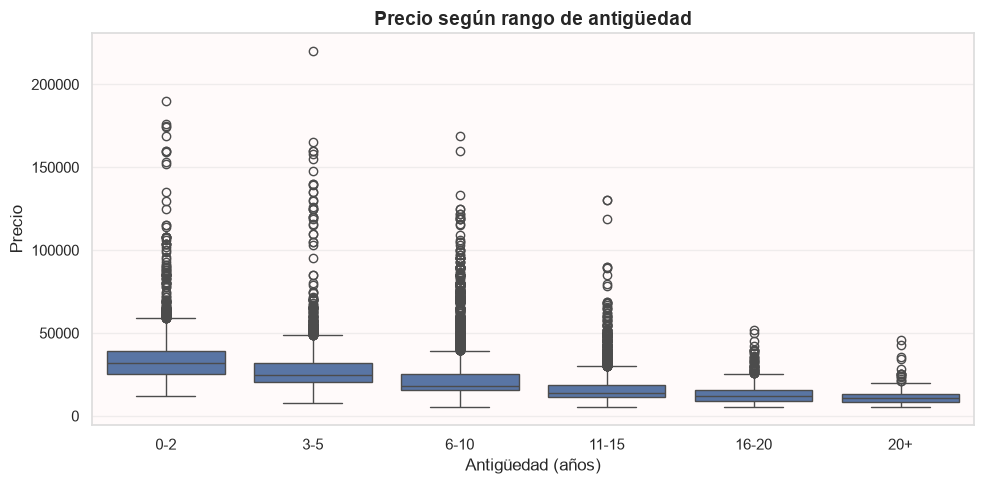

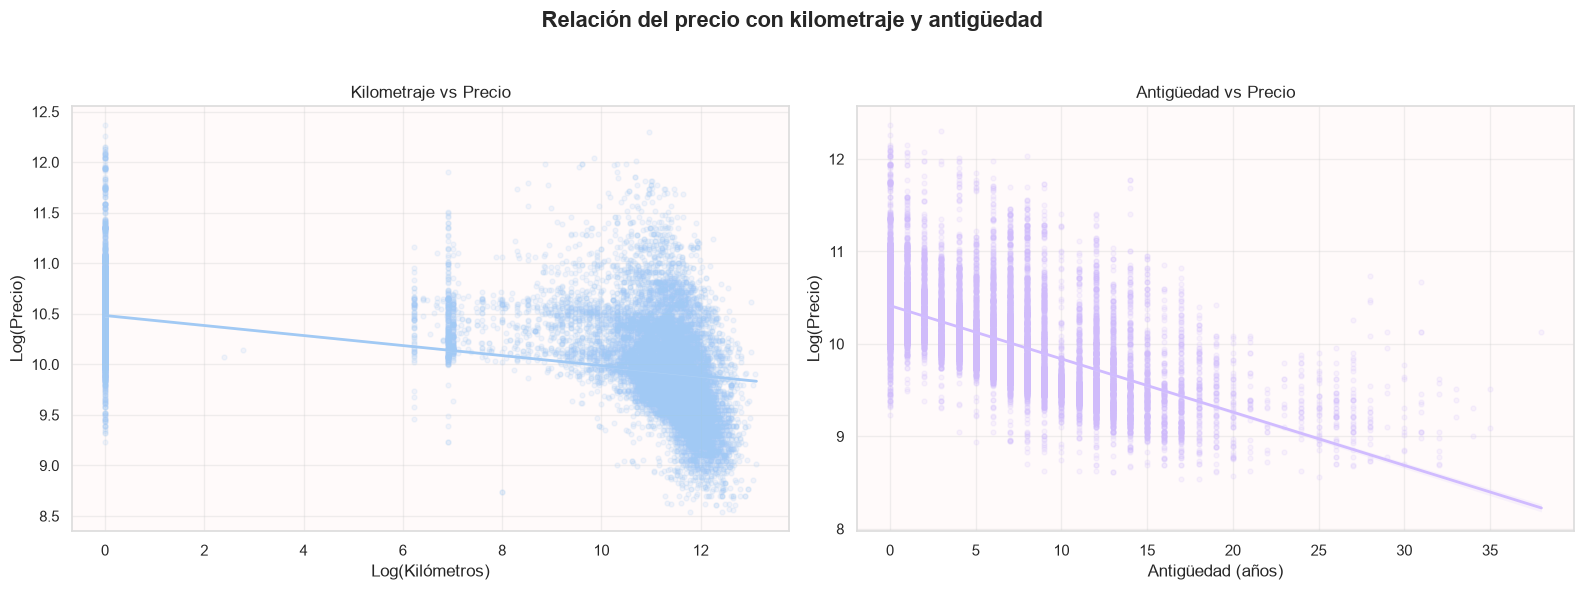

In [ ]:
data_visualizacion = pd.concat([X_train_final_sin_out, X_val_final_sin_out], ignore_index = True)
data_visualizacion = data_visualizacion[data_visualizacion["Antiguedad"] <= 50]
plot_precio_segun_rango_ant(data_visualizacion)
plot_precio_segun_antiguedad_km(data_visualizacion)

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Podemos observar, tanto para la <strong>antigüedad</strong> como para el <strong>kilometraje</strong> (plot presentado en la seccion <em>Visualizacion EDA hasta ahora</em>) una clara tendencia. El primer gráfico muestra que a mayor años de uso, el precio del vehículo (en escala logarítmica) decrece de manera consistente. Los autos de 0-2 años concentran los precios más altos, rondando entre los e^10 y e^12 USD, mientras que los de más de 20 años, se ubican en rangos más bajos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El segundo gráfico confirma lo esperado: a mayor log(Km), menor log(Precio). Los vehículos 0km tienen precios más elevados, lo cual es consistente con la realidad; y la dispersión aumenta a medida que sube el kilometraje, lo que genera el desgaste del vehículo, impactando negativamente en su precio.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El boxplot por rangos de antiguedad refuerza ambas observaciones: la mediana de precio decae progresivamente, reduciéndose la dispersión en autos más antiguos. Los outliers más extremos se localizan en el rango de los 0-2 años, correspondiendo posiblemente, a vehículos de alta gama 0km.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Con esto se deja en evidencia la importancia de ambos features en relación con el precio para la generalización del modelo predictivo a entrenar.
</p>

*¿Hay un ranking de colores de autos en cuanto a precio? ¿Cuál es el precio relativo de los distintos colores?*


In [ ]:
data_unificado = pd.concat([x_train_sin_out, x_val_sin_out]).reset_index(drop = True)

#Mediana para evitar que los otliers afecten
mediana_general = data_unificado['Precio'].median()

precio_por_color = data_unificado.groupby('Color')['Precio'].median().sort_values(ascending = False)
precio_relativo = ((precio_por_color - mediana_general) / mediana_general * 100).round(2)

display(pd.DataFrame({
    'Color': precio_por_color.index,
    'Mediana por color (USD)': precio_por_color.values,
    'Diferencia respecto a la mediana general': precio_relativo.values.round(2).astype(str) + '%'}))

,Color,Mediana por color (USD),Diferencia respecto a la mediana general
0,rosa,31803.837953,38.11%
1,amarillo,25031.982942,8.7%
2,gris,24800.000000,7.7%
3,azul,24307.036247,5.56%
4,blanco,23880.597015,3.7%
5,otro,22686.567164,-1.48%
6,bordó,21748.400853,-5.56%
7,plateado,21500.000000,-6.63%
8,negro,21321.961620,-7.41%
9,rojo,20042.643923,-12.96%


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Con esta tabla en consideracion, podemos ver que la existencia de un ranking de colores en cuanto a su precio es real. De esta forma, vehículos con colores menos frecuentes, tales como el <em>rosa</em> y el <em>amarillo</em> son los que presentan la mayor diferencia en cuanto a la mediana general de los precios. En el extremo opuesto, se tienen al <em>verde</em> y <em>dorado</em>, con una diferencia negativa, demostrando que sus precios estan porcentualmente debajo de los generales. Los colores mas comunes como el <em>gris</em>, <em>blanco</em> y <em>negro</em> se mantienen cercanos a la mediana general. Estas diferencias sugieren que el color está correlacionado con el segmento del vehículo: colores como el <em>rosa</em> y el <em>amarillo</em> tienden a aparecer en modelos deportivos o de lujo, mientras que colores atípicos como el <em>verde</em> 
se asocian a vehículos más antiguos o de menor valor de mercado.
</p>

*¿Es más barato comprar un auto a un privado o a una concesionaria/tienda? De ser así, ¿cuál es la diferencia % de precio?*


In [ ]:
#Mediana para evitar que los otliers afecten
mediana_por_vendedor = data_pre_sin_outliers.groupby('Tipo de vendedor')['Precio'].median()
mediana_particulares = mediana_por_vendedor['particular']

valores = ((mediana_por_vendedor - mediana_particulares) / mediana_particulares * 100).round(2)

display(pd.DataFrame({
    'Tipo de vendedor': valores.index,
    'Diferencia respecto a particular': valores.values.round(2).astype(str) + '%'}))

,Tipo de vendedor,Diferencia respecto a particular
0,concesionaria,13.04%
1,particular,0.0%
2,tienda,43.89%


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Se definio la mediana de los precios de los vendedores particulares como la base para la comparacion, razon por la cual se tiene que su valor porcentual es del 0.0%. Los resultados muestran que tanto las concesionarias como las tiendas publican sus vehiculos a precios superiores, siendo estas ultimas las que mayor sobreprecio presentan respecto de los privados. Esto refleja como los costos adicionales que incluyen estos canales tales como garantias y/o tipos de financiacion, afectan sus precios de venta. Más coloquialmente, el precio propuesto por las tiendas es equivalente a la compra de 1 auto y práticamente la mitad de otro.
</p>

In [ ]:
#Definimos que las marcas con mas de 35 muestras sean las validas para calcular el Coeficiente de Variacion
marcas_validas = data['Marca'].value_counts()
marcas_validas = marcas_validas[marcas_validas >= 35].index
data_filtrado = data[data['Marca'].isin(marcas_validas)]

cv = data_filtrado.groupby('Marca')['Precio'].agg(['std', 'mean'])
cv["cv"] = cv["std"] / cv["mean"]
cv.sort_values("cv")

,std,mean,cv
Marca,,,
Fiat,1.080491e+07,2.331278e+07,0.463476
Citroën,1.144210e+07,2.086296e+07,0.548441
Volkswagen,1.755692e+07,2.845617e+07,0.616981
Peugeot,1.321951e+07,2.025624e+07,0.652614
Renault,1.039727e+07,1.523884e+07,0.682287
Chevrolet,1.501753e+07,2.181144e+07,0.688516
Nissan,1.503983e+07,2.145303e+07,0.701059
Chery,8.585606e+06,1.151105e+07,0.745858
Porsche,6.914162e+04,9.031488e+04,0.765562


*¿Hay alguna marca que tenga una menor dispersión en sus precios?*

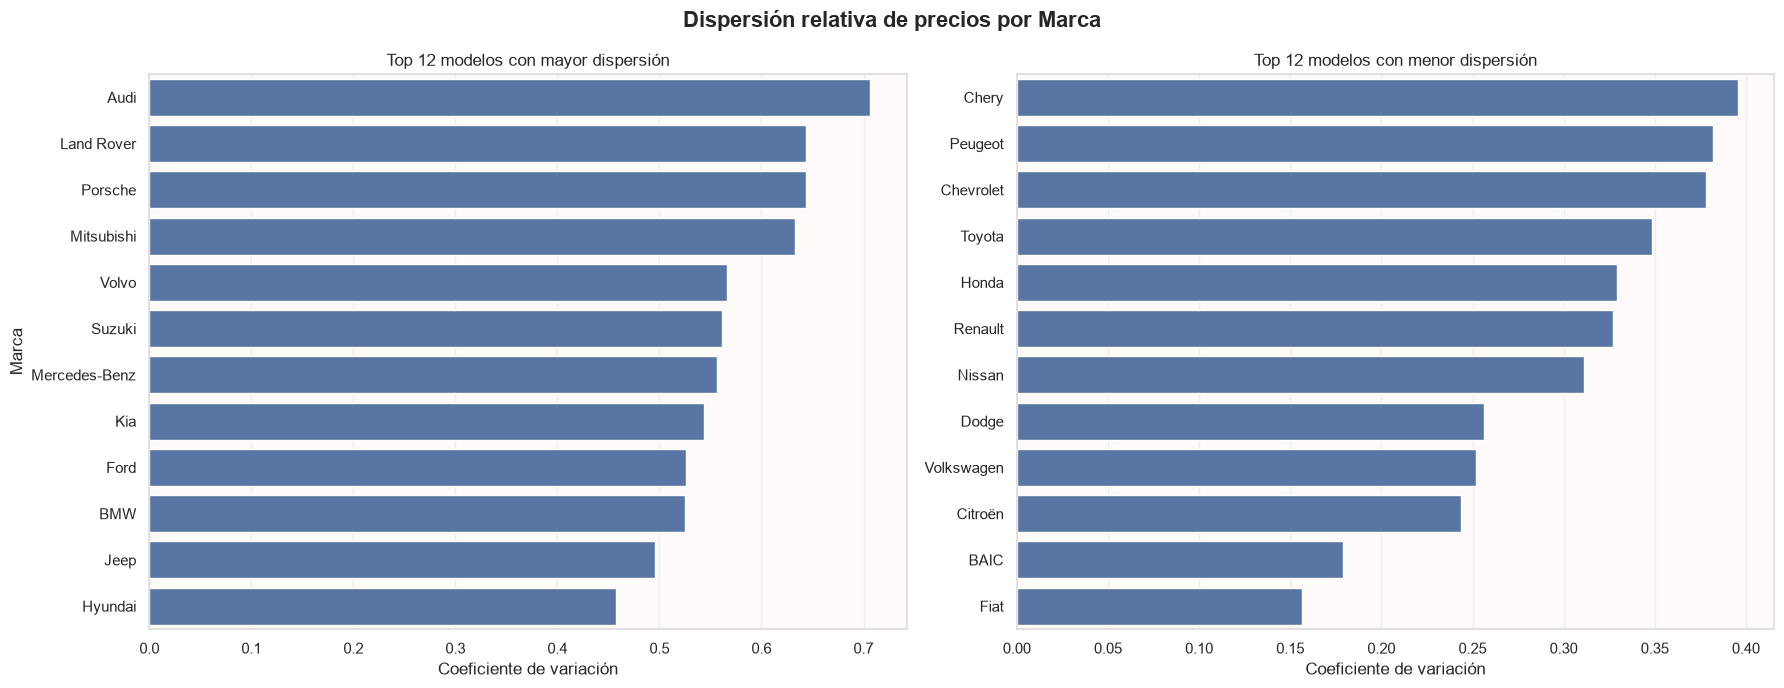

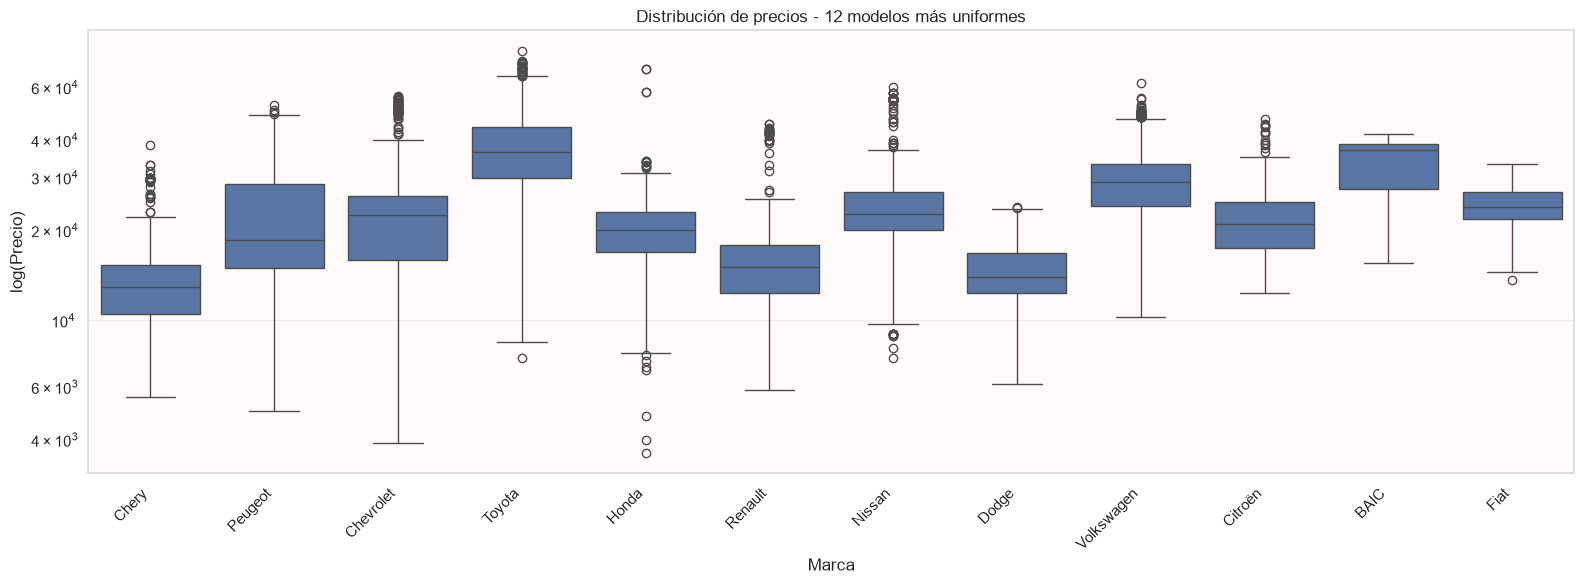

,count,mean,std,cv
Marca,,,,
Fiat,300,24093.087704,3768.593840,0.156418
BAIC,117,33450.802526,5986.260428,0.178957
Citroën,671,21435.038709,5221.010214,0.243574
Volkswagen,1895,29169.033212,7351.739242,0.252039
Dodge,179,14814.337554,3793.514545,0.256070
Nissan,983,23916.747183,7436.866998,0.310948
Renault,1379,15665.366450,5120.649378,0.326877
Honda,552,19877.425010,6545.851106,0.329311
Toyota,1215,37684.970950,13139.286677,0.348661


In [ ]:
data_pre_con_marca = data_pre_sin_outliers.copy()
data_pre_con_marca['Marca'] = data['Marca']
data_pre_con_marca = data_pre_con_marca[data_pre_con_marca["Precio"] < 350000]

plot_dispersion_por_marca(data_pre_con_marca, target= "Precio", min_muestras= 35, top_n=12)

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Las marcas con mayor dispersión resultan ser <strong>Land Rover</strong>, <strong>Porsche</strong> y <strong>BMW</strong>, tres marcas de lujo, lo cual explica este resultado: ofrecen modelos que van desde vehículos de entrada hasta vehículos de alta gama, lo que genera una gran variabilidad de precios dentro de sus modelos. El boxplot confirma esto con cajas amplias (particularmente en el caso de Porsche) y outliers con valores extremos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
En el extremo opuesto, encontramos a <strong>BAIC</strong>, <strong>Fiat</strong> y <strong>Citroën</strong>, que presentan la menor dispersión entre las marcas más predominantes del dataset. Se presentan como marcas con modelos más accesibles, los cuales se concentran en un rango de precio similar entre sí, y con un catálogo más acotado. Sus boxplots muestran cajas compactas y pocos outliers.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Lo observado a partir de la información provista coincide con lo esperable para este tipo de marcas, donde se tienen tanto modelos exclusivos como de segmento medio.
</p>

### Comparación entre modelos

### Final Model